In [44]:
import sklearn
import pandas
import seaborn

data_full = pandas.read_csv("phase0-titanic/titanic_full.csv")

grouped = data_full.groupby('pclass')['survived']

for pclass, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()                 
    percentage_survived = round(group.mean() * 100, 2)  
    
    print(f"Class {pclass}:")
    print(f"  Total in class : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")

Class 1st:
  Total in class : 324
  Total survived : 201
  Percentage survived : 62.04%

Class 2nd:
  Total in class : 284
  Total survived : 118
  Percentage survived : 41.55%

Class 3rd:
  Total in class : 709
  Total survived : 181
  Percentage survived : 25.53%

Class deck crew:
  Total in class : 66
  Total survived : 43
  Percentage survived : 65.15%

Class engineering crew:
  Total in class : 324
  Total survived : 71
  Percentage survived : 21.91%

Class restaurant staff:
  Total in class : 69
  Total survived : 3
  Percentage survived : 4.35%

Class victualling crew:
  Total in class : 431
  Total survived : 94
  Percentage survived : 21.81%



In [45]:
columns = ['pclass', 'sex', 'age', 'embarked']
x = data_full[columns]
y = data_full['survived']

x['age'] = x['age'].fillna(x['age'].median())
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])

x['is_crew'] = ~data_full['pclass'].isin(['1st','2nd','3rd'])
x['is_crew'] = x['is_crew'].astype(int)
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])
x["sex"] = x["sex"].map({"male":0, "female":1}).astype(int)

x = pandas.get_dummies(x, columns=['pclass'],drop_first=False)
x = pandas.get_dummies(x, columns=['embarked'], drop_first=False)


In [46]:
# import pandas as pd

# columns = ['pclass', 'sex', 'age', 'embarked']
# x = data_full[columns].copy()
# y = data_full['survived'].copy()

# x['age'] = x['age'].fillna(x['age'].median())
# x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])
# x["sex"] = x["sex"].map({"male":0, "female":1}).astype(int)

# x['is_crew'] = ~data_full['pclass'].isin(['1st','2nd','3rd'])
# x['is_crew'] = x['is_crew'].astype(int)

# x = pd.get_dummies(x, columns=['pclass'], drop_first=False)
# x = pd.get_dummies(x, columns=['embarked'], drop_first=False)

# # Filter dataset to only include crew
# crew_mask = x['is_crew'] == 1
# x_crew = x[crew_mask].copy()
# y_crew = y[crew_mask].copy()

# x_crew.reset_index(drop=True, inplace=True)
# y_crew.reset_index(drop=True, inplace=True)

# print("Number of crew:", x_crew['is_crew'].sum())
# print(f"Total survived : {y_crew.sum()}")
# print(f"Percentage survived : {(y_crew.mean() * 100).round(2)}%")


In [47]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

rf_model_c = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model_c = KNeighborsClassifier(n_neighbors=5)
xgb_model_c = XGBClassifier(eval_metric='logloss')
lr_model_c = LogisticRegression(max_iter=1000)

models = {
    "Random Forest": rf_model_c,
    "Logistic Regression": lr_model_c,
    "KNN": knn_model_c,
    "XGBoost": xgb_model_c
}

print("Crew Dataset Cross-Validation Results (5-Fold):\n")
cv_results_crew = {}

for name, model in models.items():
    scores = cross_val_score(model, x_crew, y_crew, cv=5, scoring='accuracy')
    cv_results_crew[name] = scores.mean()
    print(f"{name}: {scores.mean():.2f}")
    print("Scores per fold:", [f"{s:.2f}" for s in scores], "\n")

Crew Dataset Cross-Validation Results (5-Fold):

Random Forest: 0.78
Scores per fold: ['0.77', '0.80', '0.81', '0.78', '0.73'] 

Logistic Regression: 0.80
Scores per fold: ['0.81', '0.82', '0.81', '0.81', '0.75'] 

KNN: 0.76
Scores per fold: ['0.78', '0.75', '0.75', '0.76', '0.74'] 

XGBoost: 0.79
Scores per fold: ['0.82', '0.79', '0.80', '0.78', '0.75'] 



In [48]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier

# rf_model_c = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model_c.fit(x_crew, y_crew)

# importances = rf_model_c.feature_importances_
# feature_names = x_crew.columns

# nonzero_mask = importances > 0
# filtered_importances = importances[nonzero_mask]
# filtered_features = feature_names[nonzero_mask]

# # Remove all 'embarked_' columns
# mask_embarked = ~filtered_features.str.startswith('embarked_')
# filtered_importances = filtered_importances[mask_embarked]
# filtered_features = filtered_features[mask_embarked]

# filtered_importances_pct = filtered_importances * 100

# indices = np.argsort(filtered_importances_pct)[::-1]

# plt.figure(figsize=(8,5))
# bars = plt.bar(
#     range(len(filtered_importances_pct)),
#     filtered_importances_pct[indices]
# )

# plt.xticks(
#     range(len(filtered_importances_pct)),
#     filtered_features[indices],
#     rotation=45
# )

# plt.ylabel("Importance (%)")
# plt.title("Random Forest Feature Importances - Crew")

# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         height,
#         f"{height:.1f}%",
#         ha="center",
#         va="bottom",
#         fontsize=9
#     )

# plt.tight_layout()
# plt.show()


As the given data set does not include a test set, a 5 fold cross validation was added.

In [49]:
columns = ['pclass', 'sex', 'age', 'embarked']
x = data_full[columns].copy()
y = data_full['survived'].copy()

x['age'] = x['age'].fillna(x['age'].median())
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])
x["sex"] = x["sex"].map({"male":0, "female":1}).astype(int)

x['is_crew'] = ~data_full['pclass'].isin(['1st','2nd','3rd'])
x['is_crew'] = x['is_crew'].astype(int)

x = pd.get_dummies(x, columns=['pclass'], drop_first=False)
x = pd.get_dummies(x, columns=['embarked'], drop_first=False)

passenger_mask = x['is_crew'] == 0
x_passengers = x[passenger_mask].copy()
y_passengers = y[passenger_mask].copy()

x_passengers.reset_index(drop=True, inplace=True)
y_passengers.reset_index(drop=True, inplace=True)

print("Number of passengers:", x_passengers.shape[0])
print(f"Total survived : {y_passengers.sum()}")
print(f"Percentage survived : {(y_passengers.mean() * 100).round(2)}%")


Number of passengers: 1317
Total survived : 500
Percentage survived : 37.97%


In [50]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
xgb_model = XGBClassifier(eval_metric='logloss') 
lr_model = LogisticRegression(max_iter=1000)

models = {
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "XGBoost": xgb_model
}

# 5-Fold Cross-Validation on full passenger dataset
print("\nPassenger Dataset Cross-Validation Results (5-Fold):\n")
cv_results_passengers = {}

for name, model in models.items():
    scores = cross_val_score(model, x_passengers, y_passengers, cv=5, scoring='accuracy')
    cv_results_passengers[name] = scores.mean()
    print(f"{name}: {scores.mean():.2f}")
    print("Scores per fold:", [f"{s:.2f}" for s in scores], "\n")


Passenger Dataset Cross-Validation Results (5-Fold):

Random Forest: 0.78
Scores per fold: ['0.78', '0.77', '0.74', '0.80', '0.83'] 

Logistic Regression: 0.78
Scores per fold: ['0.78', '0.78', '0.78', '0.76', '0.81'] 

KNN: 0.71
Scores per fold: ['0.69', '0.74', '0.70', '0.71', '0.74'] 

XGBoost: 0.79
Scores per fold: ['0.80', '0.79', '0.76', '0.79', '0.83'] 



In [51]:
# from sklearn.ensemble import RandomForestClassifier
# import numpy as np
# import matplotlib.pyplot as plt

# rf_model_p = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model_p.fit(x_passengers, y_passengers)

# importances_p = rf_model_p.feature_importances_
# feature_names_p = x_passengers.columns

# nonzero_mask = importances_p > 0
# filtered_importances_p = importances_p[nonzero_mask]
# filtered_features_p = feature_names_p[nonzero_mask]

# mask_embarked = ~filtered_features_p.str.startswith('embarked_')
# filtered_importances_p = filtered_importances_p[mask_embarked]
# filtered_features_p = filtered_features_p[mask_embarked]

# filtered_importances_pct_p = filtered_importances_p * 100

# indices = np.argsort(filtered_importances_pct_p)[::-1]

# plt.figure(figsize=(8,5))
# bars = plt.bar(
#     range(len(filtered_importances_pct_p)),
#     filtered_importances_pct_p[indices]
# )

# plt.xticks(
#     range(len(filtered_importances_pct_p)),
#     filtered_features_p[indices],
#     rotation=45
# )

# plt.ylabel("Importance (%)")
# plt.title("Random Forest Feature Importances - Passengers")

# # Add percentage labels
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         height,
#         f"{height:.1f}%",
#         ha="center",
#         va="bottom",
#         fontsize=9
#     )

# plt.tight_layout()
# plt.show()

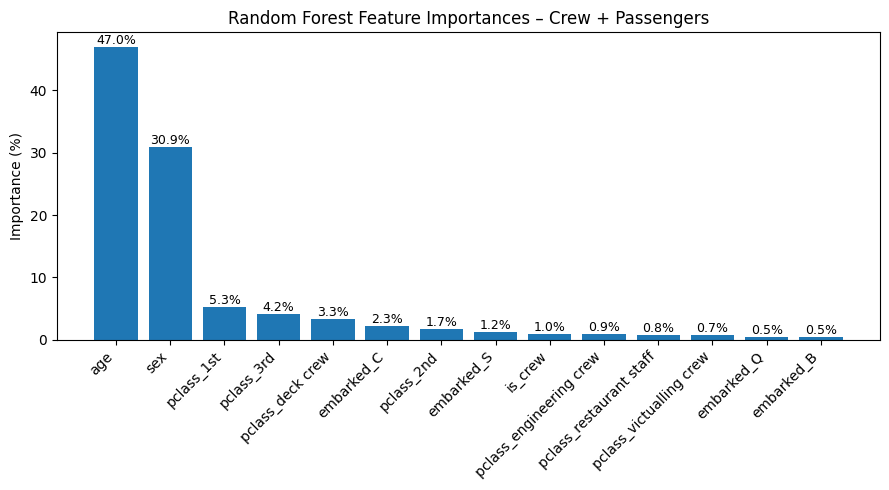

In [52]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Use full dataset (already preprocessed)
rf_model_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_full.fit(x, y)

importances = rf_model_full.feature_importances_
feature_names = x.columns

nonzero_mask = importances > 0
filtered_importances = importances[nonzero_mask]
filtered_features = feature_names[nonzero_mask]

filtered_importances_pct = filtered_importances * 100

indices = np.argsort(filtered_importances_pct)[::-1]

# Plot
plt.figure(figsize=(9,5))
bars = plt.bar(
    range(len(filtered_importances_pct)),
    filtered_importances_pct[indices]
)

plt.xticks(
    range(len(filtered_importances_pct)),
    filtered_features[indices],
    rotation=45,
    ha="right"
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances – Crew + Passengers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Conclusion

When including the crew in its survival rate , it appears that whether the induvidual is a crew or passenger, the most important features are the sex and age.